# Importing

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import skew

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import (
    SMOTE,
    BorderlineSMOTE
)

from imblearn.under_sampling import RandomUnderSampler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Data Exploring


In [139]:
df = pd.read_csv(r"D:\Samsung\project 2\adult11.csv")
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   gender          48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  salary          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [141]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### Capital Activity

In [142]:
zero_percentage = (df["capital-gain"] == 0).mean() * 100
print(f"Percentage of zeros Capital gain: {zero_percentage:.2f}%")

zero_percentage2 = (df["capital-loss"] == 0).mean() * 100
print(f"Percentage of zeros Capital loss: {zero_percentage2:.2f}%")

Percentage of zeros Capital gain: 91.74%
Percentage of zeros Capital loss: 95.33%


### Check Duplications


In [143]:
duplicated_rows = df.duplicated().sum()
print(f"Number of Duplications : {duplicated_rows}")

Number of Duplications : 52


### Check Missing Values

- Count columns with "?" Mark
- Convert "?" to NAN values for categorical columns
- Check Missing Values


In [144]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    unique_vals = df[col].unique()
    if "?" in unique_vals:
        missing_count = (df[col] == '?').sum()
        print(f"Column : {col} have {missing_count} '?' which is null")

Column : workclass have 2799 '?' which is null
Column : occupation have 2809 '?' which is null
Column : native-country have 857 '?' which is null


In [145]:
# Convert '?' to NaN 
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
df = df.replace("?", np.nan)

In [146]:
missing = df.isna().sum()
print(f"Nuumber of missing values : \n\n{missing[missing>0]}")

missing_p = (df.isnull().mean() * 100).sort_values(ascending=False)
print(f"\n\n% of missing values : \n\n{missing_p}")

Nuumber of missing values : 

workclass         2799
occupation        2809
native-country     857
dtype: int64


% of missing values : 

occupation        5.751198
workclass         5.730724
native-country    1.754637
fnlwgt            0.000000
education         0.000000
education-num     0.000000
age               0.000000
marital-status    0.000000
relationship      0.000000
gender            0.000000
race              0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
salary            0.000000
dtype: float64


### Catergorical Columns Representation :


- **column:** `workclass`  
  **description:** Type of employer and employment sector.  
  **categories:** `['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked']`

- **column:** `education`  
  **description:** Highest academic level or degree attained.  
  **categories:** `['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th', 'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate', '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool']`

- **column:** `marital-status`  
  **description:** Legal marital status of the individual.  
  **categories:** `['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced', 'Separated', 'Married-spouse-absent', 'Married-AF-spouse']`

- **column:** `occupation`  
  **description:** Primary job title or professional craft.  
  **categories:** `['Machine-op-inspct', 'Farming-fishing', 'Protective-serv', '?', 'Other-service', 'Prof-specialty', 'Craft-repair', 'Adm-clerical', 'Exec-managerial', 'Tech-support', 'Sales', 'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners', 'Armed-Forces']`

- **column:** `relationship`  
  **description:** Role and position within the household.  
  **categories:** `['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife', 'Other-relative']`

- **column:** `race`  
  **description:** Self-reported racial or ethnic background.  
  **categories:** `['Black', 'White', 'Asian-Pac-Islander', 'Other', 'Amer-Indian-Eskimo']`

- **column:** `gender`  
  **description:** Biological sex of the individual.  
  **categories:** `['Male', 'Female']`

- **column:** `native-country`  
  **description:** Country of origin or nationality.  
  **categories:** `['United-States', '?', 'Peru', 'Guatemala', 'Mexico', 'Dominican-Republic', 'Ireland', 'Germany', 'Philippines', 'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam', 'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland', 'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal', 'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica', 'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece', 'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France', 'Holand-Netherlands']`

- **column:** `salary` _(Target)_  
  **description:** Annual income threshold (classification target).  
  **categories:** `['<=50K', '>50K']`


### Check simplification

In [147]:
percentage = (df['native-country'] == 'United-States').mean() * 100
print(f"Percentage of United States in Native Country Column : {percentage}")

Percentage of United States in Native Country Column : 89.74243478973015


# Data Cleaning & Feature Engineering


### Drop Columns 

- Omitting the `fnlwgt` was excluded because it is a survey/sample weight rather than a direct individual-level predictive feature, and its interpretation is not directly relevant to the classification objective.

- Remove the `categorical education` column, as we already have the education rank; this eliminates multicollinearity and removes the need for encoding.

- Remove `relationship` column , as we already have (`marital_status` , `gender` , `age`) which sufficient to check if (husband , wife , child , un_married)


In [148]:
df = df.drop(columns=['fnlwgt', 'education'])

### Drop Duplication in Data


In [149]:
df = df.drop_duplicates()

duplication = df.duplicated().sum()
print(f"Number of Duplications : {duplication} ")

Number of Duplications : 0 


### Feature Simplification

Since the cities in the `United States` account for 90% of the total, we can group the remaining ones under "Others," while retaining the missing entries.


In [150]:
df["native-country"] = df["native-country"].apply(lambda x: ("United-States"if x == "United-States"
                                                             else "Other" if pd.notna(x)else np.nan))
#df["native-country"].value_counts() ("United-States" , "Other" )
#df["native-country"].isna().sum() still there are nulls

In [151]:
cat_cols = ["workclass", "marital-status", "occupation", "relationship", "native-country"]
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()
# =========================================================
# 2. Group Categorical Categories
# =========================================================

workclass_map = {
    "private": "Private",
    "local-gov": "Government",
    "federal-gov": "Government",
    "state-gov": "Government",
    "self-emp-not-inc": "Self-employed",
    "self-emp-inc": "Self-employed",
    "without-pay": "Other",
    "never-worked": "Other"
}

marital_map = {
    "never-married": "Single",
    "married-civ-spouse": "Married",
    "married-af-spouse": "Married",
    "married-spouse-absent": "Married",
    "divorced": "Previously-Married",
    "separated": "Previously-Married",
    "widowed": "Previously-Married"
}


occupation_map = {
    "prof-specialty": "Professional",
    "exec-managerial": "Professional",
    "tech-support": "Professional",

    "adm-clerical": "Office-Service",
    "sales": "Office-Service",
    "other-service": "Office-Service",
    "priv-house-serv": "Office-Service",

    "craft-repair": "Skilled-Manual",
    "machine-op-inspct": "Skilled-Manual",
    "transport-moving": "Skilled-Manual",
    "handlers-cleaners": "Skilled-Manual",
    "farming-fishing": "Skilled-Manual",

    "protective-serv": "Specialized",
    "armed-forces": "Specialized"
}

relationship_map = {
    "husband": "Spouse",
    "wife": "Spouse",
    "own-child": "Child",
    "not-in-family": "Other",
    "unmarried": "Other",
    "other-relative": "Other"
}


df["workclass"] = df["workclass"].map(workclass_map)

df["marital-status"] = df["marital-status"].map(marital_map)

df["occupation"] = df["occupation"].map(occupation_map)

df["relationship"] = df["relationship"].map(relationship_map)

df["native-country"] = df["native-country"].apply(
    lambda x: "US" if x == "united-states" else "Non-US"
)


### Feature Engineering

- `capital_net` (`capital-gain` - `capital-loss`):
Purpose: Combines two highly sparse, zero-inflated financial columns into a single net balance.
Benefit: Reduces dimensionality, eliminates structural multicollinearity, and directly reflects net economic gains.

- `has_capital_activity` (Binary Flag: 1 if gain/loss > 0, else 0):
Purpose: Explicitly separates non-investors from market participants.
Benefit: Solves the extreme skewness and zero-inflation problem by giving the classifier a distinct binary signal for capital market engagement.


In [152]:
df['capital_net'] = df['capital-gain'] - df['capital-loss']

df['has_capital_activity'] = ((df['capital-gain'] > 0) | (df['capital-loss'] > 0)).astype(int)

df = df.drop(columns=['capital-gain', 'capital-loss'], errors='ignore')

In [153]:
df.head(10)

,age,workclass,education-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,salary,capital_net,has_capital_activity
0,25,Private,7,Single,Skilled-Manual,Child,Black,Male,40,US,<=50K,0,0
1,38,Private,9,Married,Skilled-Manual,Spouse,White,Male,50,US,<=50K,0,0
2,28,Government,12,Married,Specialized,Spouse,White,Male,40,US,>50K,0,0
3,44,Private,10,Married,Skilled-Manual,Spouse,Black,Male,40,US,>50K,7688,1
4,18,NaN,10,Single,NaN,Child,White,Female,30,US,<=50K,0,0
5,34,Private,6,Single,Office-Service,Other,White,Male,30,US,<=50K,0,0
6,29,NaN,9,Single,NaN,Other,Black,Male,40,US,<=50K,0,0
7,63,Self-employed,15,Married,Professional,Spouse,White,Male,32,US,>50K,3103,1
8,24,Private,10,Single,Office-Service,Other,White,Female,40,US,<=50K,0,0
9,55,Private,4,Married,Skilled-Manual,Spouse,White,Male,10,US,<=50K,0,0


In [154]:
df.to_csv("Cleaned Income Data.csv", index=False)

# Target 

In [78]:
df["salary"] = df["salary"].astype(str).str.strip()

df["salary"] = df["salary"].map({"<=50K": 0,">50K": 1})

print("Target distribution:")
print(df["salary"].value_counts())

Target distribution:
salary
0    32020
1    10448
Name: count, dtype: int64


# EDA

### Check Imbalance
- Approximately 23% of individuals earn more than $50K, while the remaining 77% earn $50K or less, indicating a noticeable class imbalance in the target variable.

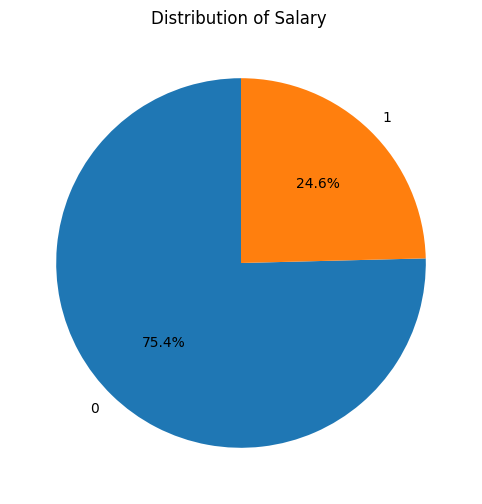

In [79]:
salary_counts = df['salary'].value_counts()

# Pie chart
plt.figure(figsize=(10,6))
plt.pie(
    salary_counts,
    labels=salary_counts.index,       
    autopct='%.1f%%',                   
    startangle=90,                       
)

plt.title("Distribution of Salary ")
plt.show()

### Salary Distribution by Capital Activity

Individuals with capital activity have a substantially higher proportion of incomes above $50K compared with individuals without capital activity.

Salary distribution by Capital Activity:
salary                    0      1
No Capital Activity   81.05  18.95
Has Capital Activity  42.73  57.27


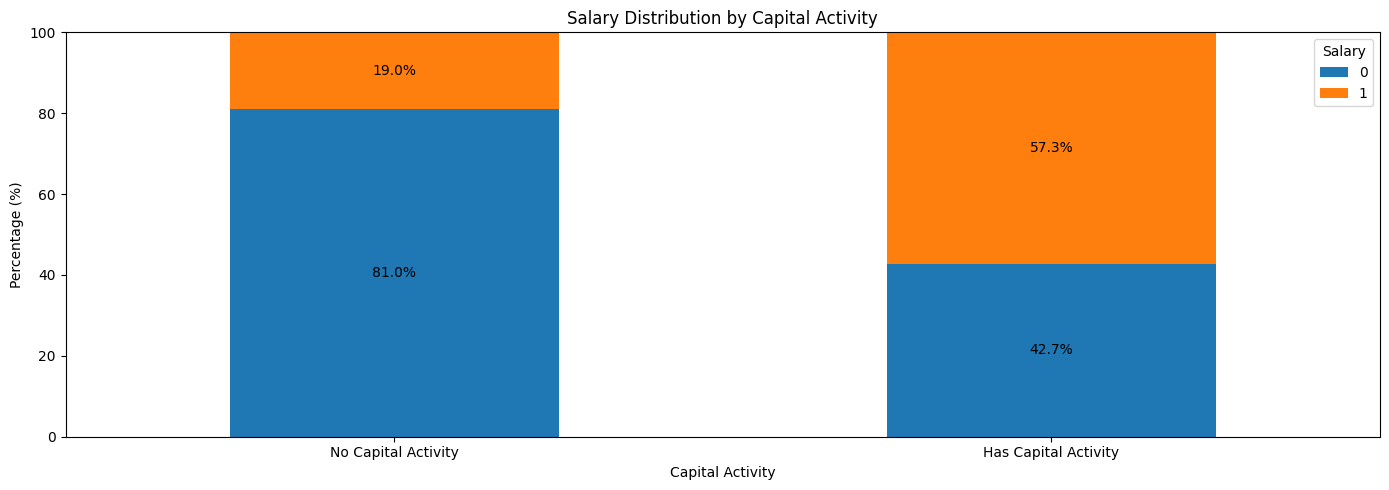

In [80]:
# 1. Calculate salary percentages within each activity group
percentage = pd.crosstab(
    df["has_capital_activity"],
    df["salary"],
    normalize="index"
) * 100

# 2. Rename activity values
percentage.index = [
    "No Capital Activity" if x == 0 else "Has Capital Activity"
    for x in percentage.index
]

# 3. Print percentages
print("Salary distribution by Capital Activity:")
print(percentage.round(2))

# 4. Plot
ax = percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 5)
)

# 5. Add percentages to bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )

plt.ylabel("Percentage (%)")
plt.xlabel("Capital Activity")
plt.title("Salary Distribution by Capital Activity")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Salary")
plt.tight_layout()
plt.show()

### Outlier Indication
- age vs. Salary: The median age for the >50K group is higher (~44 years) compared to the <=50K group (~36 years), with senior outliers (>75 years) present in both classes.

- Education-num vs. Salary: Direct positive correlation; high earners cluster around 10–13 (higher education), whereas lower earners concentrate around 9 (high school).

- Hours-per-week vs. Salary: High earners log more hours (median ~42–45 hours/week), while the <=50K segment centers strictly at 40 hours with wide part-time dispersion.

- Capital Net: Highly skewed distribution; most records sit at 0, but massive positive values (up to 100k) predominantly belong to the >50K bracket.

- Fintech & Banking: Prime prospects for investment products and premium loans are individuals aged 35+ with 12+ years of education and consistent full-time hours.

Outlier Analysis:
                Outlier_Count  Outlier_Percentage
hours-per-week           9260               21.80
capital_net              6262               14.75
education-num             323                0.76
age                       184                0.43


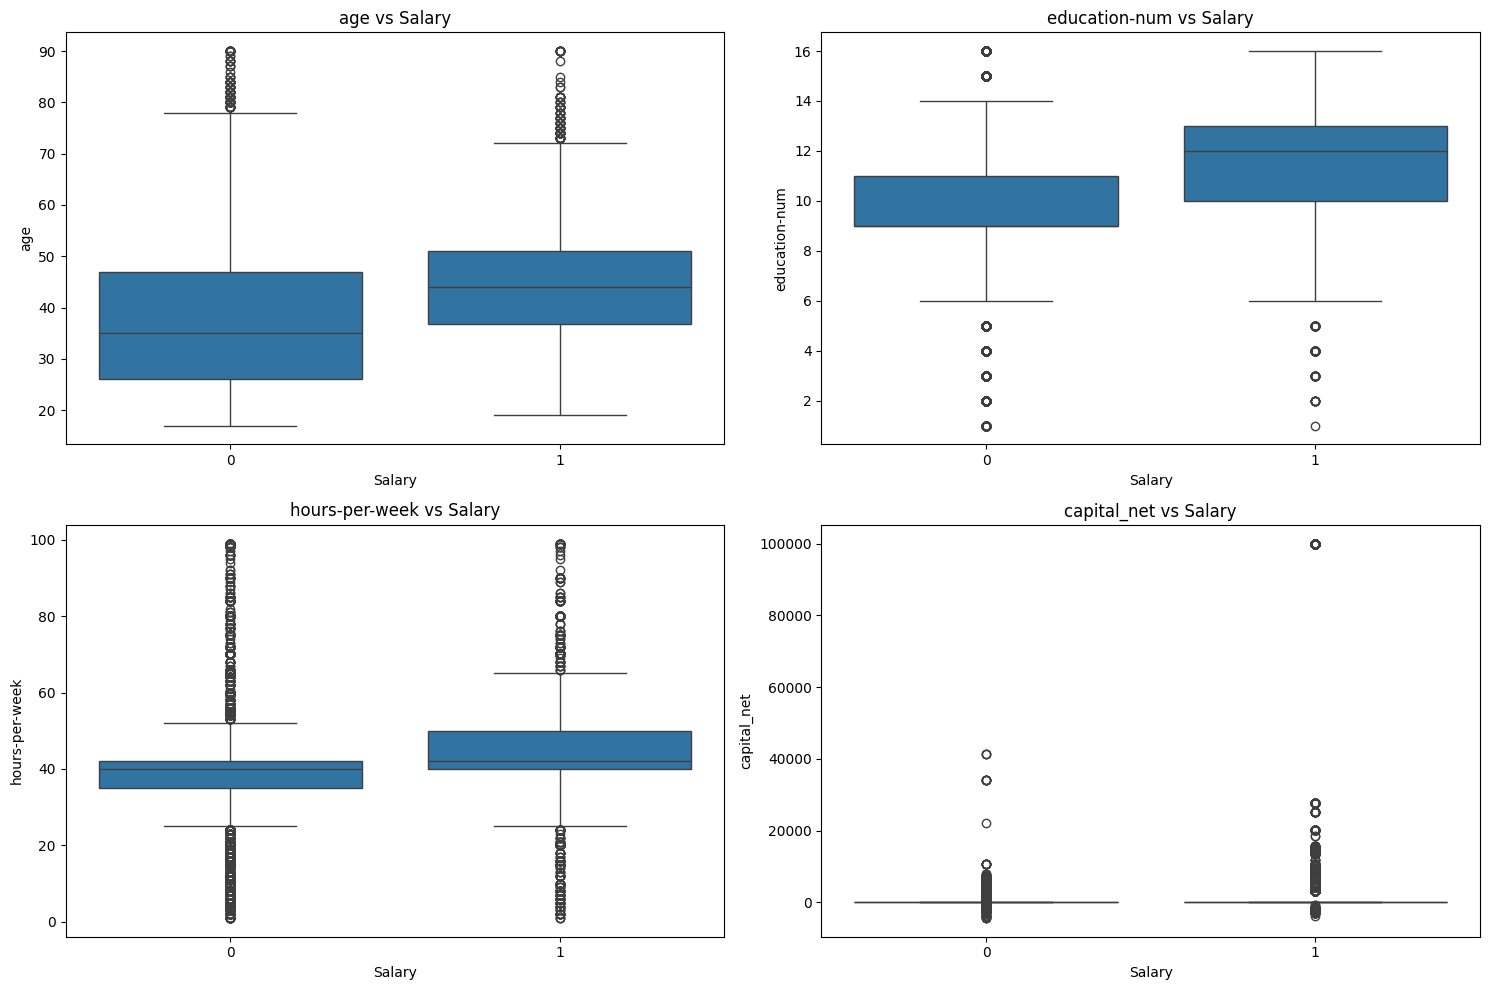

In [81]:
# ==========================================
# 1. Define numeric features
# ==========================================

numeric_features = [
    "age",
    "education-num",
    "hours-per-week",
    "capital_net"
]


# ==========================================
# 2. Function to count outliers using IQR
# ==========================================

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (series < lower_bound) | (series > upper_bound)
    
    return outliers.sum()


# ==========================================
# 3. Calculate outlier counts
# ==========================================

outlier_counts = {}

for col in numeric_features:
    outlier_counts[col] = count_outliers(df[col])


# ==========================================
# 4. Create Outlier DataFrame
# ==========================================

outlier_df = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Outlier_Count"]
)


# ==========================================
# 5. Calculate Outlier Percentage
# ==========================================

outlier_df["Outlier_Percentage"] = (
    outlier_df["Outlier_Count"] / len(df)
) * 100


# ==========================================
# 6. Sort by Outlier Count
# ==========================================

outlier_df = outlier_df.sort_values(
    by="Outlier_Count",
    ascending=False
)


# ==========================================
# 7. Display results
# ==========================================

print("Outlier Analysis:")
print(outlier_df.round(2))


# ==========================================
# 8. Boxplots by Salary
# ==========================================

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numeric_features, 1):

    plt.subplot(2, 2, i)

    sns.boxplot(
        x="salary",
        y=feature,
        data=df
    )

    plt.title(f"{feature} vs Salary")
    plt.xlabel("Salary")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

### Confusion Matrix

**Linear Correlation Insights**

* **Weak Linear Relationships:** All pairwise correlations between features are extremely low ($r \le 0.15$), confirming that variables are almost entirely linearly independent of one another.


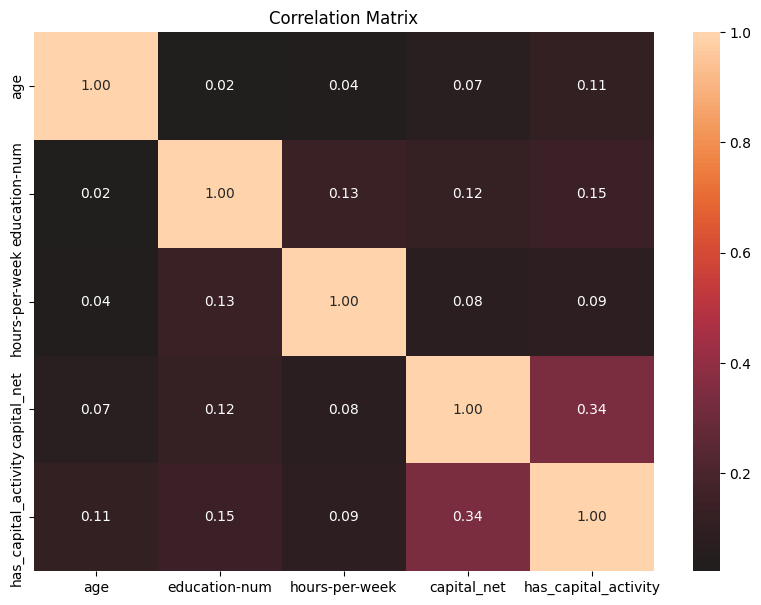

In [82]:
numeric_cols = ["age","education-num","hours-per-week","capital_net","has_capital_activity"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr,annot=True,fmt=".2f",center=0)

plt.title("Correlation Matrix")
plt.show()

### Transformation Method
- Yeo-Johnson will be applied to `capital_net`.

- Other numerical features will remain unchanged.

- The transformation will be applied inside the preprocessing pipeline to avoid data leakage.

- Yeo-Johnson Transformation: Non-linearly reshapes skewed distributions into a symmetric, Gaussian-like shape by compressing distances between extreme values in the tails while stretching clustered density in the center.

- Transforming `capital_net` reduces the influence of extreme capital values, allowing the model to capture income patterns more effectively.

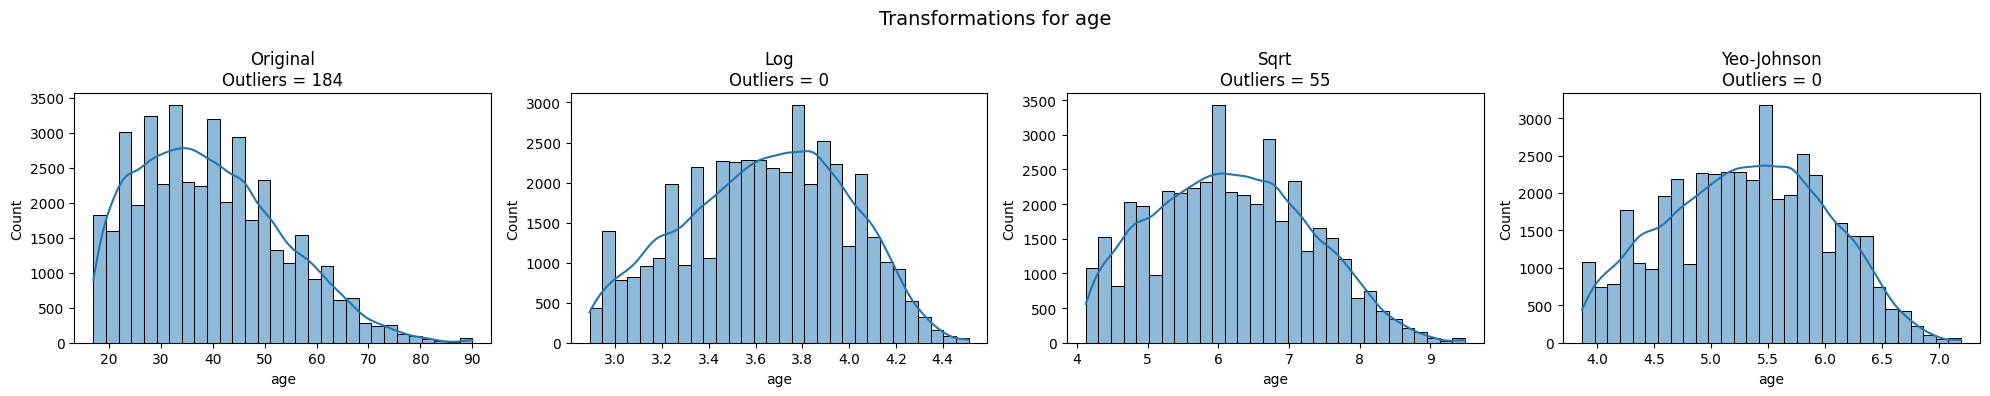

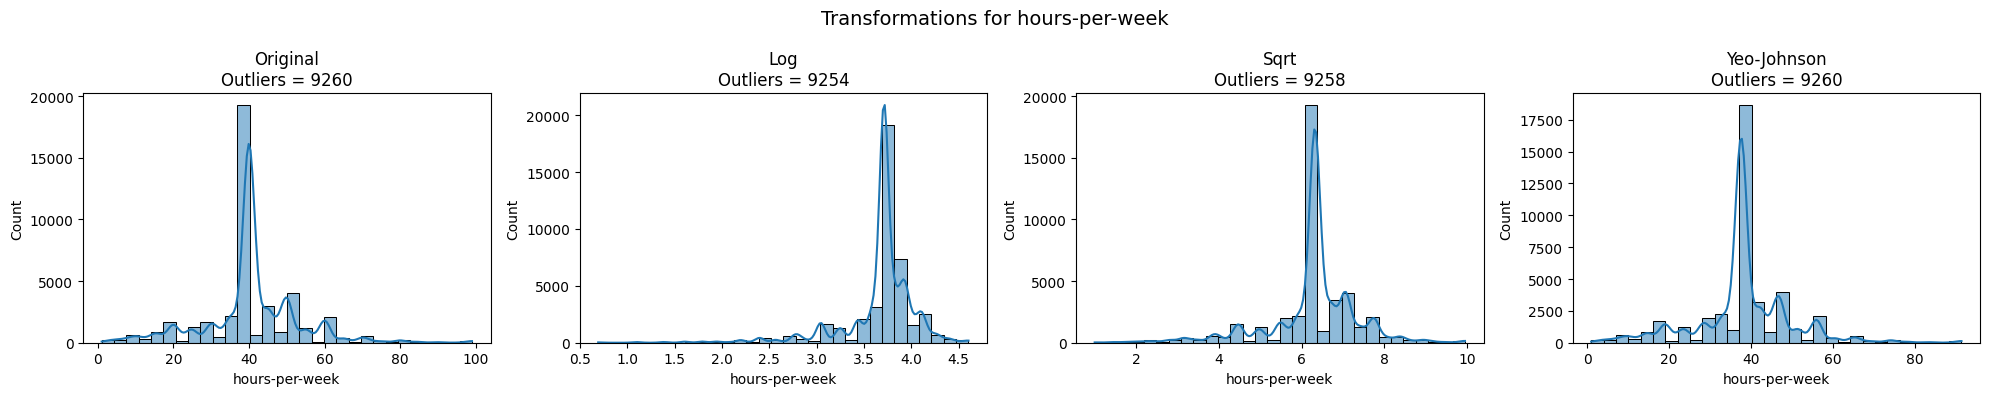

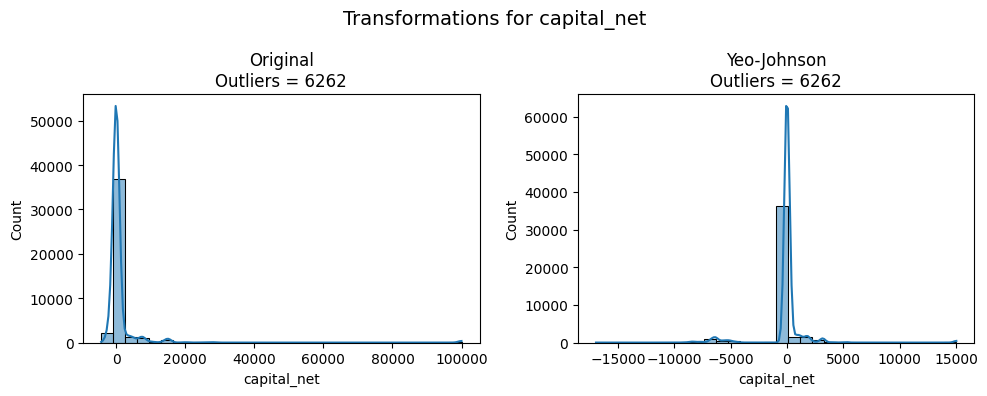

Average Outlier Counts per Transformation:
Original: 5235.33
Log: 4627.00
Sqrt: 4656.50
Yeo-Johnson: 5174.00


In [83]:
# Function to count outliers using IQR
def count_outliers(series):
    Q1 = np.percentile(series, 25)
    Q3 = np.percentile(series, 75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((series < lower) | (series > upper)).sum()


# Features suitable for transformation
transform_features = [
    "age",
    "hours-per-week",
    "capital_net"
]


# Store average outlier counts
avg_outliers = {
    "Original": [],
    "Log": [],
    "Sqrt": [],
    "Yeo-Johnson": []
}


for col in transform_features:

    data = df[col].dropna()

    # Always keep original
    transformations = {
        "Original": data
    }

    # Log and Sqrt only if all values are non-negative
    if (data >= 0).all():

        transformations["Log"] = np.log1p(data)

        transformations["Sqrt"] = np.sqrt(data)

    # Yeo-Johnson works with positive and negative values
    transformations["Yeo-Johnson"] = stats.yeojohnson(data)[0]


    # Count outliers after each transformation
    outlier_counts = {
        name: count_outliers(values)
        for name, values in transformations.items()
    }


    # Store results
    for name, count in outlier_counts.items():
        avg_outliers[name].append(count)


    # Plot distributions
    fig, axes = plt.subplots(
        1,
        len(transformations),
        figsize=(5 * len(transformations), 4)
    )

    if len(transformations) == 1:
        axes = [axes]


    for ax, (name, values) in zip(
        axes,
        transformations.items()
    ):

        sns.histplot(
            values,
            bins=30,
            kde=True,
            ax=ax
        )

        ax.set_title(
            f"{name}\nOutliers = {outlier_counts[name]}"
        )

        ax.set_xlabel(col)


    plt.suptitle(
        f"Transformations for {col}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# Average outlier counts
print("Average Outlier Counts per Transformation:")

for name, counts in avg_outliers.items():

    if counts:
        print(
            f"{name}: {np.mean(counts):.2f}"
        )

In [84]:

for col in ["age", "hours-per-week", "capital_net"]:

    data = df[col].dropna()

    print(f"\n{col}")
    print(f"Original Skewness: {skew(data):.3f}")

    if (data >= 0).all():
        print(f"Log Skewness: {skew(np.log1p(data)):.3f}")
        print(f"Sqrt Skewness: {skew(np.sqrt(data)):.3f}")

    print(
        f"Yeo-Johnson Skewness: "
        f"{skew(stats.yeojohnson(data)[0]):.3f}"
    )


age
Original Skewness: 0.534
Log Skewness: -0.143
Sqrt Skewness: 0.180
Yeo-Johnson Skewness: -0.016

hours-per-week
Original Skewness: 0.256
Log Skewness: -2.313
Sqrt Skewness: -0.946
Yeo-Johnson Skewness: 0.208

capital_net
Original Skewness: 11.073
Yeo-Johnson Skewness: 0.809


# Balance Dataset

In [85]:
def balance_dataset(df, target_size=20000, random_state=42):

    minority = df[df["salary"] == 1]
    majority = df[df["salary"] == 0]

    minority_count = len(minority)

    majority_needed = target_size - minority_count

    if majority_needed > len(majority):
        raise ValueError("Not enough majority samples.")

    majority_sample = majority.sample(
        n=majority_needed,
        random_state=random_state
    )

    balanced_df = pd.concat(
        [minority, majority_sample],
        axis=0
    )
    # Shuffle
    balanced_df = balanced_df.sample(
            frac=1,
            random_state=random_state
        ).reset_index(drop=True)
    
    return balanced_df
    

In [86]:
df_balanced = balance_dataset(df,target_size=20000,random_state=42)

In [87]:
# Check balance
print(df_balanced["salary"].value_counts())
print("Shape:", df_balanced.shape)

salary
1    10448
0     9552
Name: count, dtype: int64
Shape: (20000, 13)


# Features and Target

In [88]:
X = df_balanced.drop(columns=["salary"])
y = df_balanced["salary"]

# Data Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

# Columns

In [90]:
numeric_cols = ["age", "education-num", "hours-per-week"]
yeo_cols = ["capital_net"]
categorical_cols = ["workclass", "marital-status", "occupation", "relationship", "race", "native-country" ]
binary_cols = ["gender", "has_capital_activity"]

# Preprocessing 
- Standard Scaling
- Yeo-johnson Transformation
- One Hot Encoding

In [91]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("capital", Pipeline([("yeo", PowerTransformer(method="yeo-johnson")), ("scaler", StandardScaler())]), yeo_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
        ("binary", OneHotEncoder(handle_unknown="ignore", drop="first"), binary_cols),
    ]
)

# Random Forst Pipleline

In [92]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ( "model", RandomForestClassifier( n_estimators=100, random_state=42, n_jobs=-1 ))
])


# Feature Importance

**Feature Importance Insights**

* **Primary Predictor (`age` ~ 28.1%):** Age is the single most dominant factor driving income prediction, serving as a strong proxy for accumulated work experience and career seniority.
* **Core Socioeconomic Drivers (~ 31.6% combined):** 
  * `education-num` (16.4%) and `hours-per-week` (15.3%) closely follow, confirming that educational attainment and weekly labor commitment are essential thresholds for earning `>50K`.
* **Household & Capital Influence (~ 31.7% combined):**
  * `marital-status` features (`Single` at 12.3% and `Previously-Married` at 8.6%) exhibit substantial weight, reflecting the strong historical link between dual-income/marital stability and household income reporting.
  * Direct capital gains (`capital_net` at 10.9% and `has_capital_activity` at 3.6%) represent key wealth indicators that trigger high-earner classifications.
* **Low Impact Demographic Features:** Demographic factors like `gender` (~3.3%) and racial categories (`race_*` all below 0.7%) contribute minimally to tree splits compared to economic, educational, and experience-based variables.

                           Feature  Importance
0                         num__age    0.269498
1         cat__relationship_Spouse    0.148888
2              num__hours-per-week    0.135851
3               num__education-num    0.129264
4             capital__capital_net    0.094139
5          cat__relationship_Other    0.061716
6     cat__occupation_Professional    0.035317
7   binary__has_capital_activity_1    0.027520
8              binary__gender_Male    0.023059
9           cat__workclass_Private    0.014422
10  cat__occupation_Skilled-Manual    0.013511
11          cat__native-country_US    0.010742
12    cat__workclass_Self-employed    0.009572
13                 cat__race_White    0.007157
14                 cat__race_Black    0.005863
15    cat__race_Asian-Pac-Islander    0.003567
16     cat__occupation_Specialized    0.003429
17             cat__occupation_nan    0.002715
18              cat__workclass_nan    0.002226
19                 cat__race_Other    0.001301


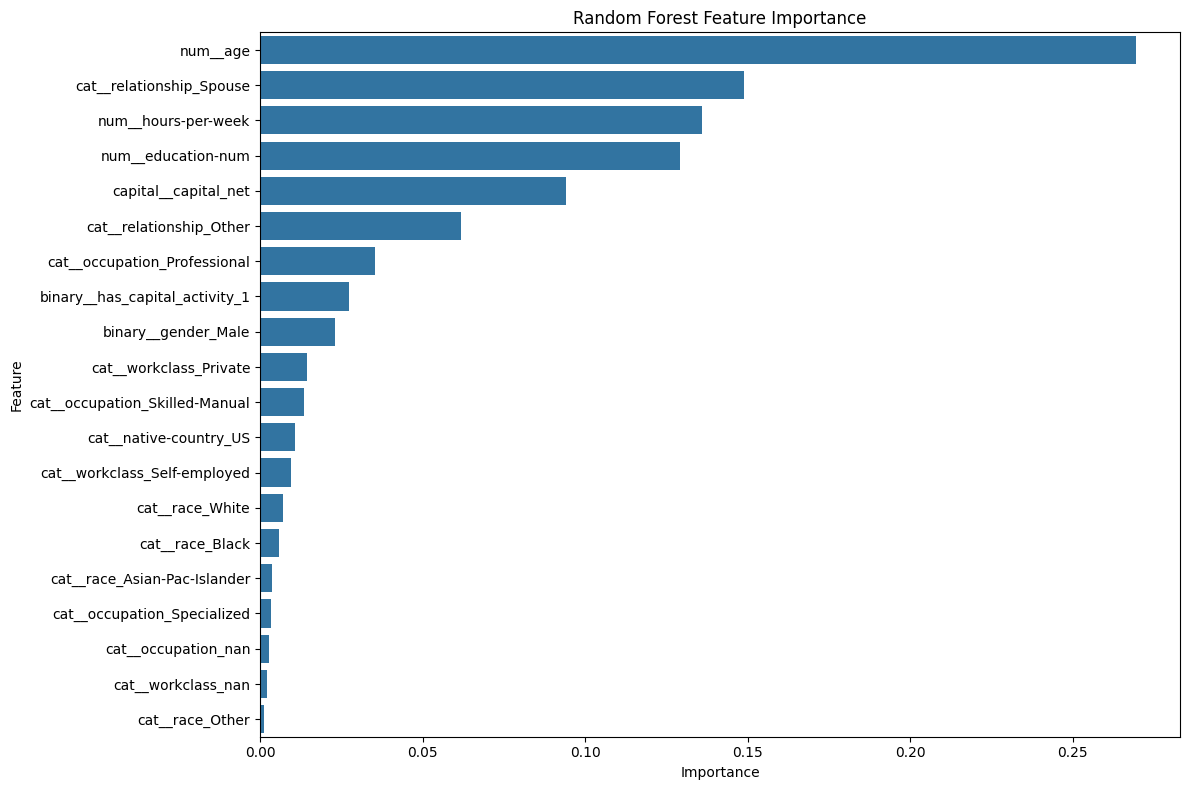

In [93]:
# ============================================
# Get Feature Importance
# ============================================
pipeline.fit(X_train, y_train)

# Get fitted preprocessor
preprocessor_fitted = pipeline.named_steps["preprocessor"]

# Get fitted Random Forest
rf_model = pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get importance
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top 20
print(feature_importance_df.head(20))


# ============================================
# Plot Top 20 Features
# ============================================

top_features = feature_importance_df.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### K_Fold Cross Validation

In [94]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_results = cross_validate(pipeline,X_train,y_train,cv=cv,
                            scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],n_jobs=-1)

In [95]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education-num',
                                                   'hours-per-week']),
                                                 ('capital',
                                                  Pipeline(steps=[('yeo',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['capital_net']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'native-country']),
                                                 ('binary',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender',
                                                   'has_capital_activity'])])),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

### Test

In [96]:
predictions = pipeline.predict(X_test)

### Evaluation

In [97]:
print(classification_report(y_test,predictions,target_names=["<=50K", ">50K"]))

              precision    recall  f1-score   support

       <=50K       0.81      0.79      0.80      1910
        >50K       0.81      0.83      0.82      2090

    accuracy                           0.81      4000
   macro avg       0.81      0.81      0.81      4000
weighted avg       0.81      0.81      0.81      4000



### Accuracy Matrix

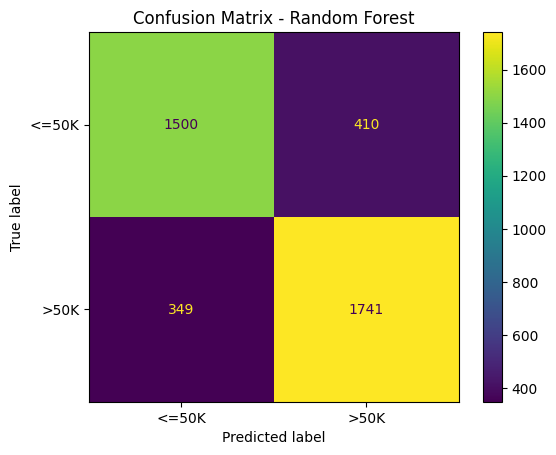

In [98]:
# Predictions on test set
y_pred = pipeline.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

### RF Performance
**Performance Breakdown (`>50K` Class)**

* **Detection Rate (Recall = 85%):** The model successfully captured **85%** of actual high earners (1,775 correctly identified out of 2,090 total; missed only 315).
* **Prediction Reliability (Precision = 80%):** When predicting an individual earns `>50K`, the model is correct **80%** of the time (1,775 true positives out of 2,226 positive flags; 451 false alarms).

---

**Performance Breakdown (`<=50K` Class)**

* **Detection Rate (Recall = 76%):** Correctly captured **76%** of individuals earning `<=50K` (1,459 out of 1,910 total).
* **Prediction Reliability (Precision = 82%):** When predicting an individual earns `<=50K`, it is correct **82%** of the time (1,459 true negatives out of 1,774 total `<=50K` predictions).

---

**Overall Metrics**

* **Accuracy (81%):** Correctly classified 3,234 out of the 4,000 total test samples.
* **F1-Score Balance:** Achieved **0.82** for `>50K` and **0.79** for `<=50K`, demonstrating robust, balanced performance across both target segments.

# PCA Random Forest 

In [99]:
pca_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("pca", PCA( n_components=0.95, random_state=42)),

    ("model", RandomForestClassifier( n_estimators=100, random_state=42, n_jobs=-1 ))
])

### Train

In [100]:
pca_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education-num',
                                                   'hours-per-week']),
                                                 ('capital',
                                                  Pipeline(steps=[('yeo',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['capital_net']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'native-country']),
                                                 ('binary',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender',
                                                   'has_capital_activity'])])),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

### Test

In [101]:
y_pred_pca = pca_pipeline.predict(X_test)
y_proba_pca = pca_pipeline.predict_proba(X_test)[:, 1]

### PCA

In [102]:
pca = pca_pipeline.named_steps["pca"]

print("Original Features:",
      len(pca_pipeline.named_steps["preprocessor"].get_feature_names_out()))

print("PCA Components:", pca.n_components_)

print("Explained Variance:",
      pca.explained_variance_ratio_.sum())

Original Features: 21
PCA Components: 12
Explained Variance: 0.9623310861717593


### Report

In [103]:
y_pred_pca = pca_pipeline.predict(X_test)

print("PCA + Random Forest Classification Report")
print(classification_report( y_test, y_pred_pca, target_names=["<=50K", ">50K"]))

PCA + Random Forest Classification Report
              precision    recall  f1-score   support

       <=50K       0.80      0.75      0.78      1910
        >50K       0.79      0.83      0.81      2090

    accuracy                           0.79      4000
   macro avg       0.79      0.79      0.79      4000
weighted avg       0.79      0.79      0.79      4000



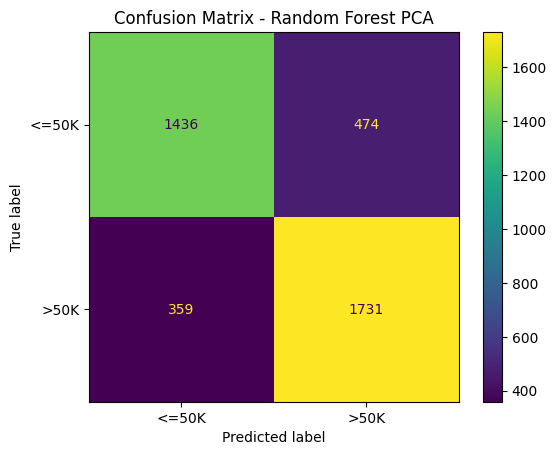

In [104]:
# Predictions on test set
y_pred_pca = pca_pipeline.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pca)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest PCA")
plt.show()

### PCA + Random Forest Performance

* **Performance on `>50K` Class:**
  * **Detection Rate (Recall = 85%):** Successfully identified **85%** of high earners (1,774 out of 2,090; missed 316).
  * **Prediction Reliability (Precision = 79%):** When predicting `>50K`, the model was correct **79%** of the time (1,774 true positives against 485 false alarms).

---

* **Performance on `<=50K` Class:**
  * **Detection Rate (Recall = 75%):** Captured **75%** of lower-income individuals (1,425 out of 1,910).
  * **Prediction Reliability (Precision = 82%):** When predicting `<=50K`, precision reached **82%** (1,425 correct classifications out of 1,741 total `<=50K` predictions).

---

* **Overall Impact of PCA vs. Baseline RF:**
  * **Slight Degradation Across Metrics:** Overall Accuracy dropped from **81% to 80%**, with total correct predictions falling slightly from 3,234 to 3,199.
  * **Why PCA Did Not Help:** PCA is a linear projection technique, whereas Tree-based ensembles naturally capture orthogonal axis-aligned splits on original features. Compressing features via PCA discarded non-linear variance and stripped away the interpretability of raw features (like `age` and `education-num`) without delivering any performance gains.

# XG_Boast Pipleline

In [105]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42,eval_metric="logloss",n_jobs=-1))
])

### K_Fold Cross Validation

In [106]:
cv_results_xgb = cross_validate(xgb_pipeline,X_train,y_train,cv=cv,
    scoring=["accuracy","precision","recall","f1","roc_auc"],n_jobs=-1)

### Train

In [107]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'education-num',
                                                   'hours-per-week']),
                                                 ('capital',
                                                  Pipeline(steps=[('yeo',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['capital_net']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'r...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### Test

In [108]:
y_pred_xgb = xgb_pipeline.predict(X_test)

print(classification_report( y_test, y_pred_xgb, target_names=["<=50K", ">50K"]))

              precision    recall  f1-score   support

       <=50K       0.88      0.80      0.84      1910
        >50K       0.83      0.90      0.87      2090

    accuracy                           0.86      4000
   macro avg       0.86      0.85      0.85      4000
weighted avg       0.86      0.86      0.86      4000



### Accuracy Matrix

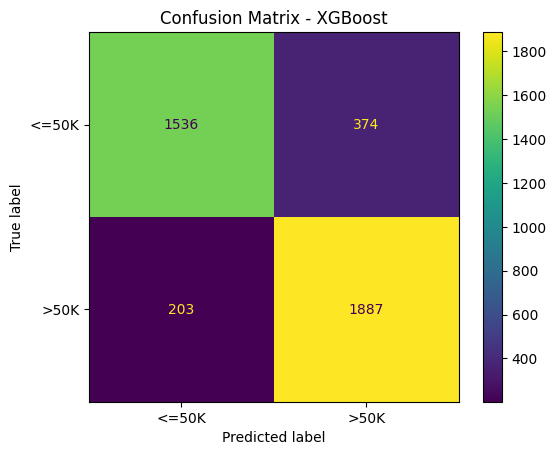

In [109]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
)

disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

### XG_Boast Performance
**Performance Breakdown (`>50K` Class) - XGBoost**

* **Detection Rate (Recall = 90%):** The model successfully captured **90%** of actual high earners (1,876 correctly identified out of 2,090 total; missed only 214).
* **Prediction Reliability (Precision = 83%):** When predicting an individual earns `>50K`, the model is correct **83%** of the time (1,876 true positives out of 2,271 positive flags; 395 false alarms).

---

**Performance Breakdown (`<=50K` Class) - XGBoost**

* **Detection Rate (Recall = 79%):** Correctly captured **79%** of individuals earning `<=50K` (1,515 out of 1,910 total).
* **Prediction Reliability (Precision = 88%):** When predicting an individual earns `<=50K`, it is correct **88%** of the time (1,515 true negatives out of 1,729 total `<=50K` predictions).

---

**Overall Metrics & RF Comparison**

* **Accuracy (85%):** Correctly classified 3,391 out of the 4,000 total test samples (a clear 4% jump over Random Forest's 81%).
* **F1-Score:** Achieved **0.86** for `>50K` and **0.83** for `<=50K`, outperforming Random Forest across both classes and cutting high-earner misses from 315 down to 214.

# XGBOAST with Grid Search

In [110]:
xgbgs_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", XGBClassifier(random_state=42,eval_metric="logloss",n_jobs=-1))
])

### Grid Search

In [111]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

### GridSearchCV

In [112]:
grid_search = GridSearchCV(estimator=xgb_pipeline,param_grid=param_grid,cv=5,scoring="f1",n_jobs=-1,verbose=1)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}

Best CV F1:
0.8532879733805819


### Best XGBoost Model

In [113]:
best_xgb = grid_search.best_estimator_

### Report

In [114]:
y_pred_xgbgs = best_xgb.predict(X_test)

print(classification_report(y_test,y_pred_xgbgs,target_names=["<=50K", ">50K"]))

              precision    recall  f1-score   support

       <=50K       0.88      0.81      0.84      1910
        >50K       0.84      0.90      0.87      2090

    accuracy                           0.85      4000
   macro avg       0.86      0.85      0.85      4000
weighted avg       0.86      0.85      0.85      4000



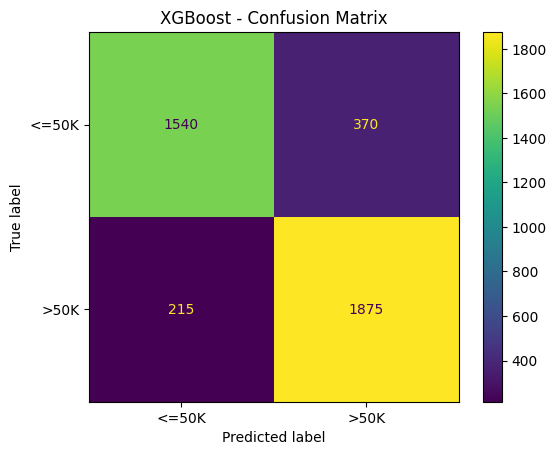

In [115]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgbgs,
    display_labels=["<=50K", ">50K"]
)

plt.title("XGBoost - Confusion Matrix")
plt.show()

# ROC | AUC Curve

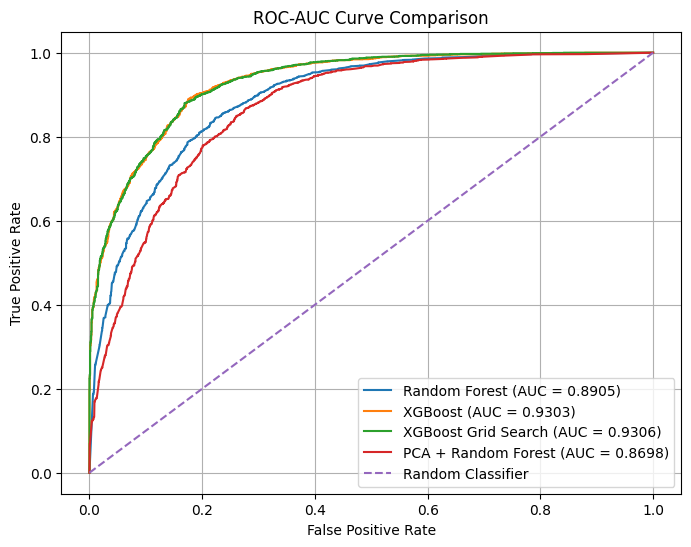

In [116]:
# Get probabilities for positive class (>50K)
rf_proba = pipeline.predict_proba(X_test)[:, 1]
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_gs_proba = best_xgb.predict_proba(X_test)[:, 1]
pca_rf_proba = pca_pipeline.predict_proba(X_test)[:, 1]


# ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_xgb_gs, tpr_xgb_gs, _ = roc_curve(y_test, xgb_gs_proba)
fpr_pca_rf, tpr_pca_rf, _ = roc_curve(y_test, pca_rf_proba)


# AUC
auc_rf = roc_auc_score(y_test, rf_proba)
auc_xgb = roc_auc_score(y_test, xgb_proba)
auc_xgb_gs = roc_auc_score(y_test, xgb_gs_proba)
auc_pca_rf = roc_auc_score(y_test, pca_rf_proba)


# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.4f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {auc_xgb:.4f})"
)

plt.plot(
    fpr_xgb_gs,
    tpr_xgb_gs,
    label=f"XGBoost Grid Search (AUC = {auc_xgb_gs:.4f})"
)

plt.plot(
    fpr_pca_rf,
    tpr_pca_rf,
    label=f"PCA + Random Forest (AUC = {auc_pca_rf:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve Comparison")

plt.legend()
plt.grid()

plt.show()

### ROC-AUC Comparison 

* **Quantitative Results:**
  * **XGBoost (Baseline):** Best discriminative performance with **AUC = 0.9232** (orange curve).
  * **XGBoost Grid Search:** Virtually identical performance with **AUC = 0.9230** (green curve).
  * **Random Forest:** Lower overall separation capability with **AUC = 0.8808** (blue curve).

---

* **Technical Insights:**
  * **Boosting Outperforms Bagging:** XGBoost outperforms Random Forest by ~0.04 AUC, maintaining a higher True Positive Rate across virtually all False Positive Rate thresholds.
  * **Grid Search Saturation:** Tuning produced negligible variation compared to default parameters, indicating the baseline configuration was already near-optimal or the search grid was too constrained.
  * **Model Recommendation:** Select the **Baseline XGBoost** model; it achieves peak predictive power without unnecessary tuning overhead.

# Compare Prediction

In [117]:
# ============================================
# Predictions
# ============================================

rf_pred = pipeline.predict(X_test)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_gs_pred = best_xgb.predict(X_test)
pca_rf_pred = pca_pipeline.predict(X_test)


# ============================================
# Probabilities for ROC-AUC
# ============================================

rf_proba = pipeline.predict_proba(X_test)[:, 1]
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_gs_proba = best_xgb.predict_proba(X_test)[:, 1]
pca_rf_proba = pca_pipeline.predict_proba(X_test)[:, 1]


# ============================================
# Model Comparison
# ============================================

models = {
    "Random Forest": (rf_pred, rf_proba),
    "XGBoost": (xgb_pred, xgb_proba),
    "XGBoost Grid Search": (xgb_gs_pred, xgb_gs_proba),
    "PCA + Random Forest": (pca_rf_pred, pca_rf_proba)
}

results = []

for model_name, (pred, proba) in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })


comparison_df = pd.DataFrame(results)


# ============================================
# Sort by F1
# ============================================

comparison_df = comparison_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


# ============================================
# Large Styled Table
# ============================================

display(
    comparison_df.style
    .set_properties(**{
        "text-align": "center",
        "font-size": "16px",
        "padding": "14px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("font-size", "17px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "14px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "14px")
            ]
        }
    ])
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.8558,0.8346,0.9029,0.8674,0.9303
1,XGBoost Grid Search,0.8538,0.8352,0.8971,0.8651,0.9306
2,Random Forest,0.8103,0.8094,0.8330,0.8210,0.8905
3,PCA + Random Forest,0.7917,0.7850,0.8282,0.8061,0.8698
